In [1]:
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
from sqlalchemy import create_engine

username = 'root'
password = '7999590423'
host = 'localhost'
port = '3306'
database = 'superstore_db'

engine = create_engine(
    f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}'
)

In [3]:
with engine.connect() as conn:
    print('Connected to MYSQL successfully')

Connected to MYSQL successfully


In [16]:
## Data Reading :

query = """
SELECT 
   o.order_id,
    o.customer_id,
    o.product_id,
    o.order_date,
    o.ship_date,
    o.ship_mode,
    o.country,
    o.state,
    o.city,
    o.region,
    o.postal_code,
    o.sales,
    o.quantity,
    o.discount,
    o.profit,
    o.shipping_cost,

    p.product_name,
    p.category,
    p.sub_category,

    c.customer_name,
    c.segment,

    COALESCE(r.Returned,'No') AS returned,
    r.market

FROM orders o
JOIN products p
ON o.product_id = p.product_id

JOIN customers c
ON o.customer_id = c.customer_id

LEFT JOIN returns r
ON o.order_id = r.`Order ID`;
"""
df = pd.read_sql(query, engine)
df

,order_id,customer_id,product_id,order_date,ship_date,ship_mode,country,state,city,region,...,discount,profit,shipping_cost,product_name,category,sub_category,customer_name,segment,returned,market
0,CG-2014-7660,PH-8790,FUR-ADV-10000002,2014-05-08,2014-05-13,Standard Class,Democratic Republic of the Congo,Kinshasa,Kinshasa,Africa,...,0.0,40.26,6.11,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings,Patricia Hirasaki,Home Office,No,None
1,IZ-2014-4660,TB-11190,FUR-ADV-10000002,2014-09-08,2014-09-15,Standard Class,Iraq,Baghdad,Baghdad,EMEA,...,0.0,20.13,4.03,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings,Thomas Brumley,Home Office,No,None
2,RW-2012-8200,SG-10890,FUR-ADV-10000108,2012-02-20,2012-02-24,Standard Class,Rwanda,Kigali,Kigali,Africa,...,0.0,1.92,10.80,"Advantus Clock, Erganomic",Furniture,Furnishings,Susan Gilcrest,Corporate,No,None
3,LI-2011-9980,PM-9135,FUR-ADV-10000108,2011-04-13,2011-04-15,Second Class,Liberia,Montserrado,Monrovia,Africa,...,0.0,0.96,9.27,"Advantus Clock, Erganomic",Furniture,Furnishings,Peter McVee,Home Office,No,None
4,MO-2012-8110,AR-540,FUR-ADV-10000108,2012-05-10,2012-05-17,Standard Class,Morocco,Grand Casablanca,Casablanca,Africa,...,0.0,0.48,2.83,"Advantus Clock, Erganomic",Furniture,Furnishings,Andy Reiter,Consumer,No,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51290,MZ-2013-3540,EH-4005,TEC-STA-10004542,2013-04-19,2013-04-23,Standard Class,Mozambique,Sofala,Beira,Africa,...,0.0,12.00,4.68,"StarTech Calculator, Durable",Technology,Machines,Erica Hernandez,Home Office,No,None
51291,TU-2014-8160,SC-10260,TEC-STA-10004542,2014-07-07,2014-07-13,Standard Class,Turkey,Istanbul,Istanbul,EMEA,...,0.6,-18.05,1.62,"StarTech Calculator, Durable",Technology,Machines,Scott Cohen,Corporate,No,None
51292,TU-2011-790,CC-2145,TEC-STA-10004834,2011-11-03,2011-11-08,Standard Class,Turkey,Adana,Adana,EMEA,...,0.6,-107.83,13.61,"StarTech Receipt Printer, Red",Technology,Machines,Charles Crestani,Consumer,No,None
51293,NI-2013-7410,CD-1920,TEC-STA-10004834,2013-08-28,2013-09-03,Standard Class,Nigeria,Kano,Kano,Africa,...,0.7,-37.73,5.77,"StarTech Receipt Printer, Red",Technology,Machines,Carlos Daly,Consumer,No,None


In [17]:
 # Changing the data type of shipping_date and order_date column 

df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])


In [18]:
df.dtypes

order_id                 object
customer_id              object
product_id               object
order_date       datetime64[ns]
ship_date        datetime64[ns]
ship_mode                object
country                  object
state                    object
city                     object
region                   object
postal_code              object
sales                   float64
quantity                  int64
discount                float64
profit                  float64
shipping_cost           float64
product_name             object
category                 object
sub_category             object
customer_name            object
segment                  object
returned                 object
market                   object
dtype: object

In [19]:
# # dropping the market column

df.drop(columns = ['market'], inplace = True)

# Regional & Geographic Analysis:

### Sales and profit by region

In [30]:
query = """
SELECT
    region, 
    ROUND(SUM(sales), 2)  AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit
FROM orders
GROUP BY region 
ORDER BY total_sales DESC;
"""
sales_and_profit_by_region = pd.read_sql(query, engine)
sales_and_profit_by_region.head(5)

,region,total_sales,total_profit
0,Central,2822303.89,311403.75
1,South,1600907.17,140355.94
2,North,1248166.53,194597.41
3,Oceania,1100185.69,120089.63
4,Southeast Asia,884423.95,17852.36


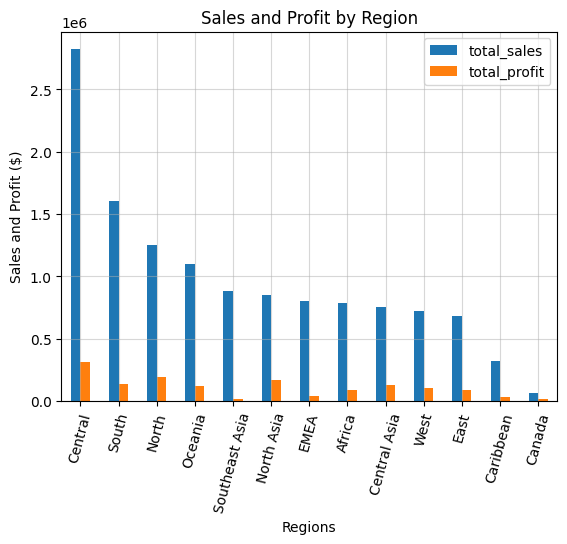

In [34]:
sales_and_profit_by_region.plot(x = 'region',
                                y = ['total_sales','total_profit'],
                                kind = 'bar'
                               )
plt.title('Sales and Profit by Region')
plt.xlabel('Regions')
plt.ylabel('Sales and Profit ($)')
plt.xticks(rotation = 75)
plt.grid(alpha = 0.5)

plt.show()

### Region wise profit margin :

In [35]:
query = """
SELECT 
    region,
    ROUND(SUM(profit) / SUM(sales) * 100, 2) AS profit_margin_pct
FROM orders 
GROUP BY region;
"""
region_wise_profit_margin = pd.read_sql(query, engine)

region_wise_profit_margin.head(5)

,region,profit_margin_pct
0,East,13.48
1,Oceania,10.92
2,Central,11.03
3,Africa,11.34
4,West,14.94


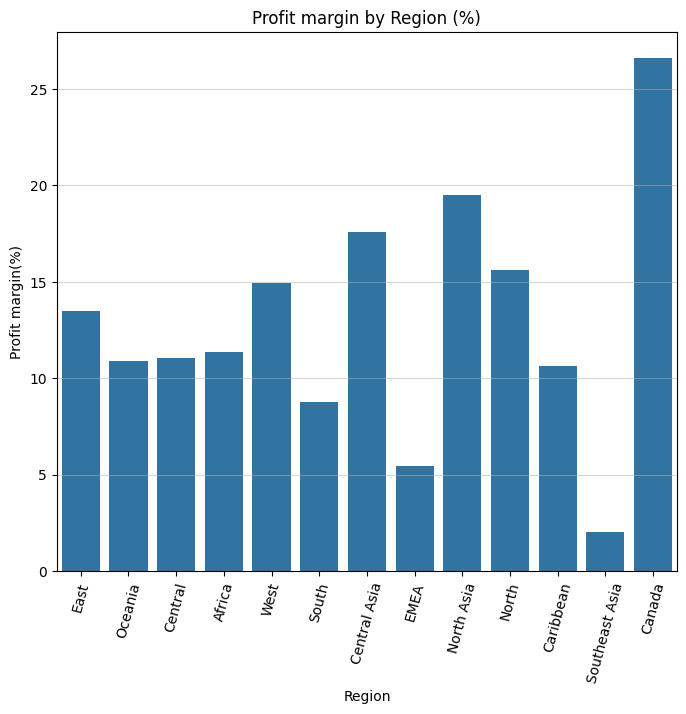

In [84]:
plt.figure(figsize = (8,7))

sns.barplot(x = 'region',
        y = 'profit_margin_pct',
        data = region_wise_profit_margin
       )

plt.title('Profit margin by Region (%)')
plt.xlabel('Region')
plt.ylabel('Profit margin(%)')
plt.xticks(rotation = 75)
plt.grid(axis = 'y',alpha = 0.5)

plt.show()

### State Level perfomance by sales :

In [43]:
query = """
SELECT
    state,
    ROUND(SUM(sales), 2) AS total_sales
FROM orders
GROUP BY State
ORDER BY total_sales DESC
LIMIT 10;
"""
sales_state_perfomance = pd.read_sql(query, engine)

In [44]:
sales_state_perfomance.head(5)

,state,total_sales
0,England,485171.22
1,California,457687.68
2,Ile-de-France,317822.72
3,New York,310876.20
4,New South Wales,270487.46


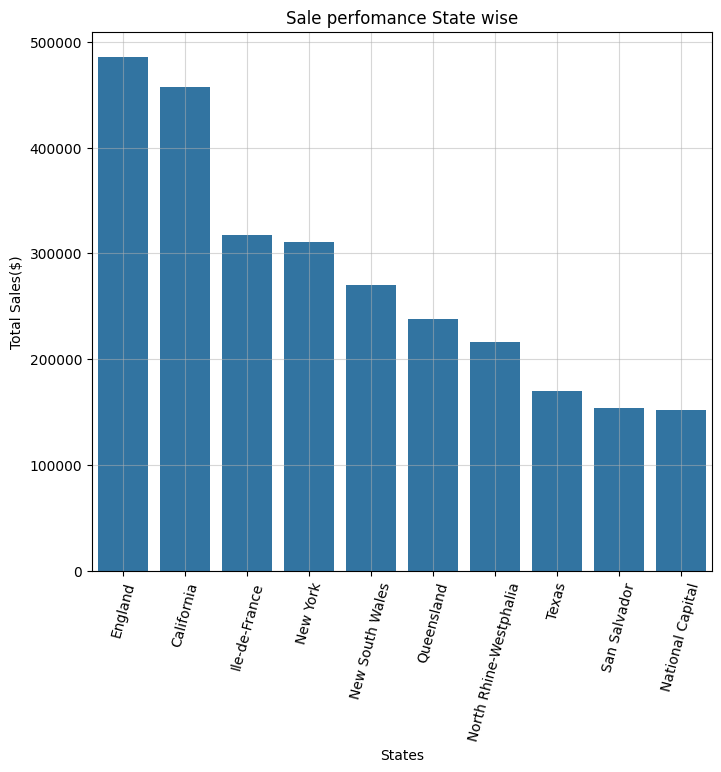

In [47]:
plt.figure(figsize = (8,7))

sns.barplot(x = 'state',
            y = 'total_sales',
            data = sales_state_perfomance
           )
plt.title('Sale perfomance State wise')
plt.xlabel('States')
plt.ylabel('Total Sales($)')
plt.xticks(rotation = 75)
plt.grid(alpha = 0.5)

plt.show()

### State that generates negative profit:

In [53]:
query = """
SELECT 
    state,
    ROUND(SUM(profit), 2) AS total_profit
FROM orders
GROUP BY state 
HAVING total_profit < 0
ORDER BY total_profit DESC
LIMIT 10;
"""
state_negative_profit = pd.read_sql(query, engine)

state_negative_profit.head(5)

,state,total_profit
0,T�chira,-0.54
1,Ayacucho,-1.31
2,Cojedes,-3.34
3,T?nh C?n Th?,-4.40
4,Matabeleland North,-5.33


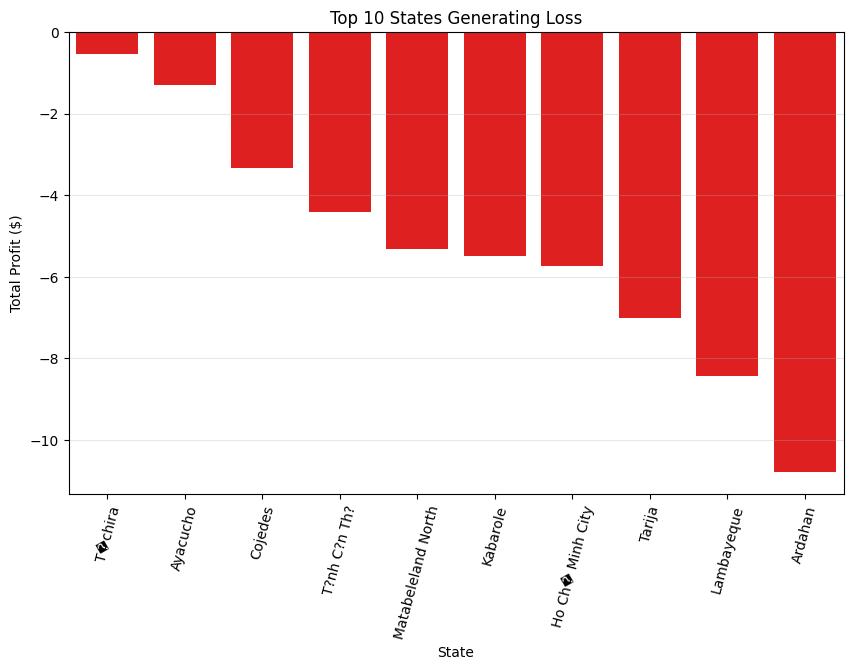

In [60]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='state',
    y='total_profit',
    data=state_negative_profit,
    color='red'
)

plt.title('Top 10 States Generating Loss')
plt.xlabel('State')
plt.ylabel('Total Profit ($)')

plt.xticks(rotation=75)

plt.grid(axis='y', alpha=0.3)

plt.show()

### Average discount by Region:

In [63]:
query = """
SELECT 
    Region,
    ROUND(AVG(Discount), 2) AS avg_discount
FROM
    orders
GROUP BY Region 
ORDER BY avg_discount DESC
LIMIT 10;
"""

avg_discount_by_region = pd.read_sql(query, engine)

avg_discount_by_region.head()

,Region,avg_discount
0,Southeast Asia,0.27
1,EMEA,0.20
2,Africa,0.16
3,East,0.15
4,Oceania,0.15


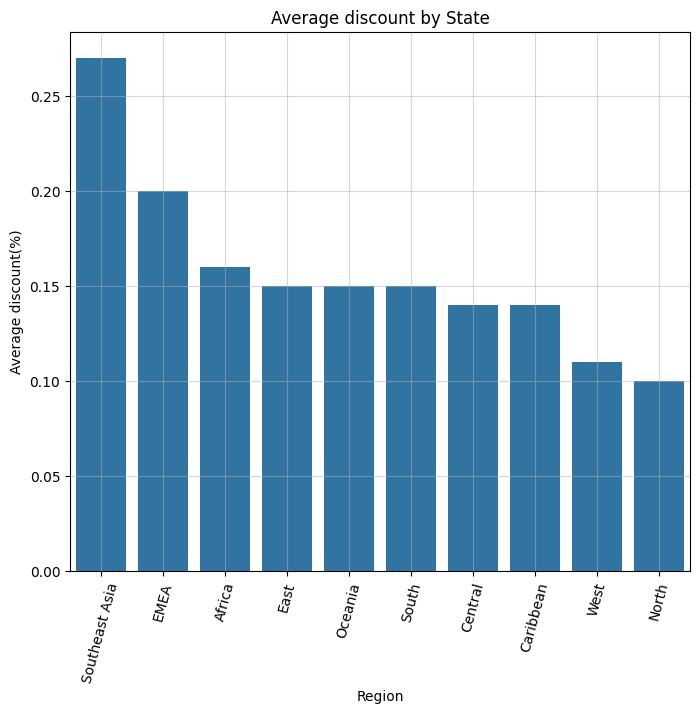

In [64]:
plt.figure(figsize=(8,7))

sns.barplot(x = 'Region',
            y = 'avg_discount',
            data = avg_discount_by_region
           )

plt.title('Average discount by State')
plt.xlabel('Region')
plt.ylabel('Average discount(%)')
plt.grid(alpha = 0.5)
plt.xticks(rotation = 75)

plt.show()





### Region wise order volumn:

In [65]:
query="""
SELECT 
    region,
    COUNT(*) AS order_volume
FROM orders
GROUP BY region 
ORDER BY order_volume DESC
LIMIT 10;
"""
region_wise_order_volume = pd.read_sql(query, engine)

region_wise_order_volume


,region,order_volume
0,Central,11117
1,South,6645
2,EMEA,5029
3,North,4785
4,Africa,4587
5,Oceania,3487
6,West,3203
7,Southeast Asia,3129
8,East,2848
9,North Asia,2338


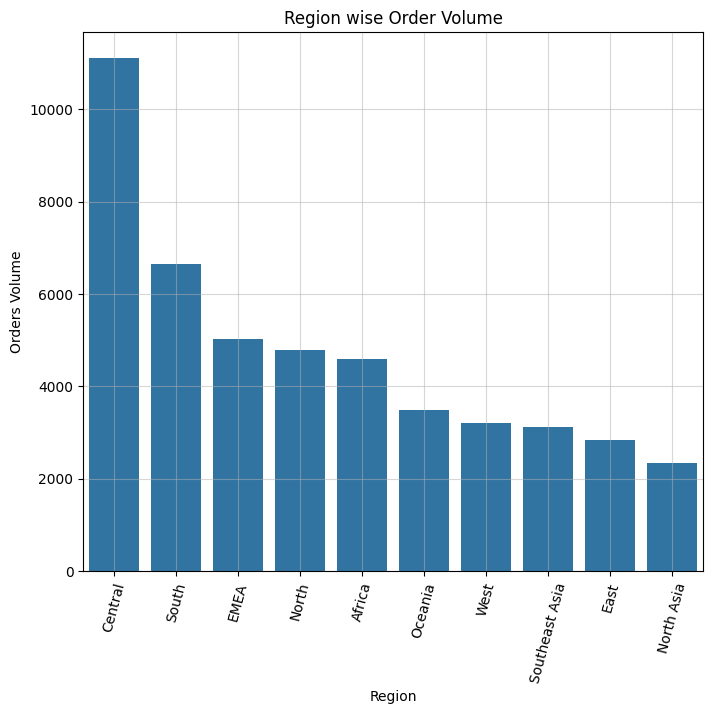

In [67]:
plt.figure(figsize=(8,7))

sns.barplot(x = 'region',
            y = 'order_volume',
            data = region_wise_order_volume
           )

plt.title('Region wise Order Volume')
plt.xlabel('Region')
plt.xticks(rotation = 75)

plt.ylabel('Orders Volume')
plt.grid(alpha = 0.5)

plt.show()

### Top cities by sales

In [68]:
query = """
SELECT 
    city,
    ROUND(SUM(sales), 2) AS total_sales
FROM orders
GROUP BY City
ORDER BY total_sales DESC
LIMIT 10;
"""

cities_by_sales = pd.read_sql(query, engine)

cities_by_sales

,city,total_sales
0,New York City,256368.12
1,Los Angeles,175851.33
2,Manila,120887.30
3,Seattle,119540.74
4,San Francisco,112669.09
5,Philadelphia,109077.09
6,Sydney,101945.68
7,Jakarta,94321.35
8,London,86945.86
9,Mexico City,85728.58


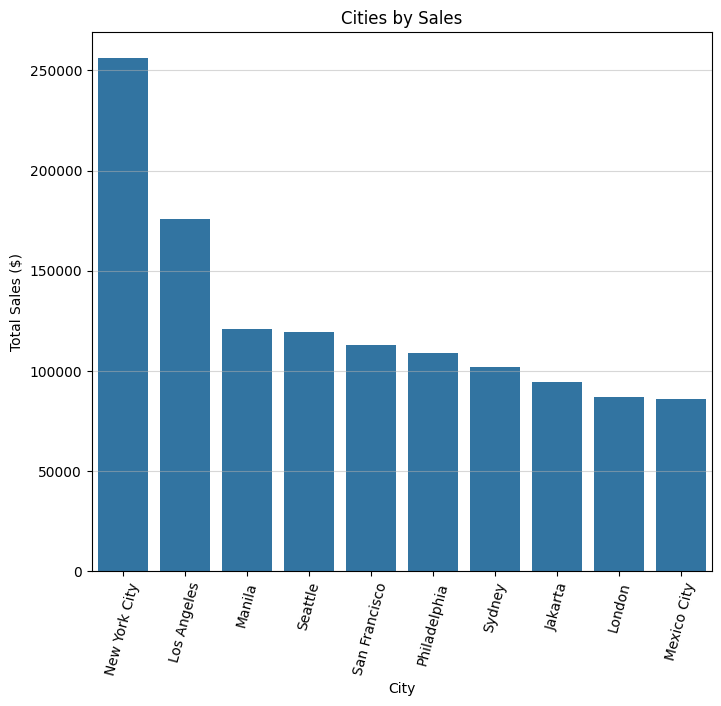

In [73]:
plt.figure(figsize=(8,7))

sns.barplot(x = 'city',
            y = 'total_sales',
            data = cities_by_sales
           )
plt.title('Cities by Sales')
plt.xlabel('City')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation = 75)
plt.grid(axis = 'y',alpha = 0.5)

plt.show()

### Cities with high sales but negative profit:

In [74]:
query =""" 
SELECT 
    city,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(sales), 2) AS total_sales
FROM orders
GROUP BY City
HAVING total_sales > 5000
    AND total_profit < 0
ORDER BY total_sales DESC
LIMIT 10;
"""
city_highsales_lowprofit = pd.read_sql(query, engine)

city_highsales_lowprofit

,city,total_profit,total_sales
0,Manila,-11158.58,120887.30
1,Philadelphia,-13837.83,109077.09
2,Santo Domingo,-3569.62,78713.64
3,Bangkok,-7124.89,76049.86
4,Houston,-10153.48,64504.71
5,Chicago,-6654.55,48539.59
6,Tegucigalpa,-15007.36,48048.96
7,Jacksonville,-2323.80,44713.18
8,Ho Chi Minh City,-5.74,43260.22
9,Bandung,-33.08,36957.04


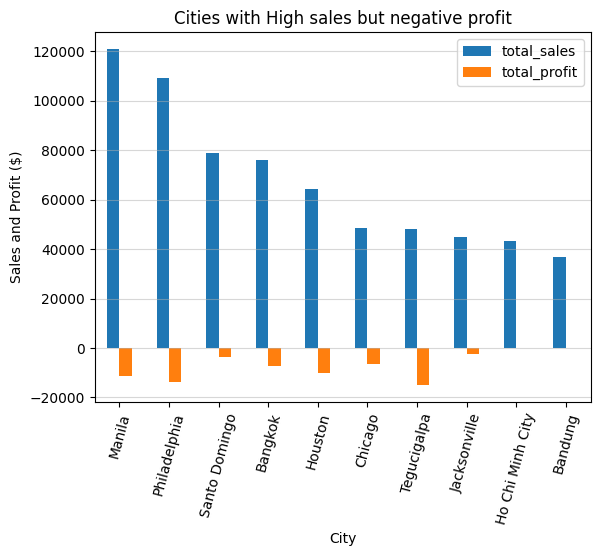

In [77]:
city_highsales_lowprofit.plot(x = 'city',
                                y = ['total_sales','total_profit'],
                                kind = 'bar'
                               )
plt.title('Cities with High sales but negative profit')
plt.xlabel('City')
plt.ylabel('Sales and Profit ($)')
plt.xticks(rotation = 75)
plt.grid(axis ='y',alpha = 0.5)

plt.show()

### Product category perfomance by region :

In [82]:
query = """
SELECT 
    region,
    category, 
    ROUND(SUM(sales), 2) AS total_sales
FROM orders o  
JOIN products p 
ON o.product_id = p.product_id
GROUP BY region, category 
ORDER BY region, total_sales DESC
LIMIT 10;
"""
product_category_by_region = pd.read_sql(query, engine)

product_category_by_region


,region,category,total_sales
0,Africa,Technology,322367.04
1,Africa,Office Supplies,266755.70
2,Africa,Furniture,194650.63
3,Canada,Office Supplies,30034.08
4,Canada,Technology,26298.81
5,Canada,Furniture,10595.28
6,Caribbean,Furniture,118372.39
7,Caribbean,Technology,116333.06
8,Caribbean,Office Supplies,89575.44
9,Central,Technology,1038449.98


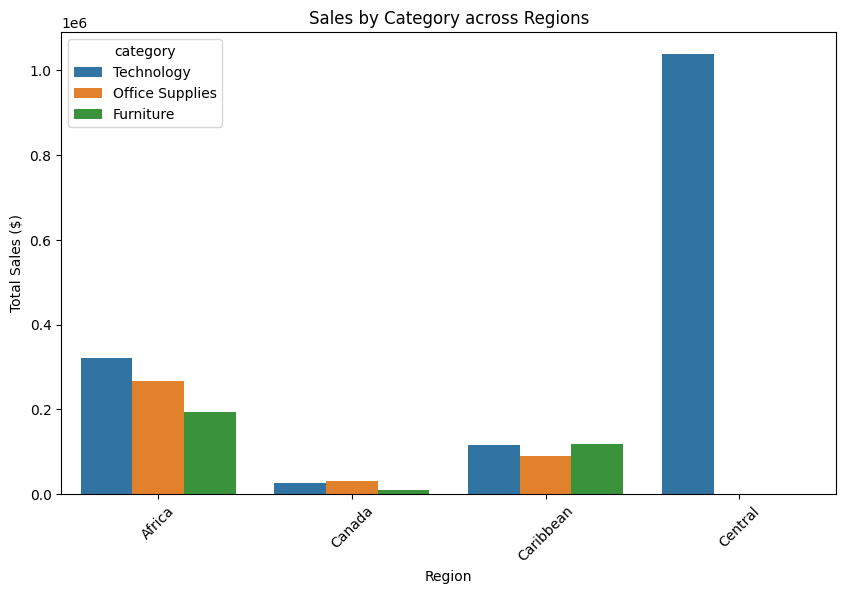

In [83]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='region',
    y='total_sales',
    hue='category',
    data=product_category_by_region
)

plt.title('Sales by Category across Regions')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')

plt.xticks(rotation=45)

plt.show()

# Summary:

## Key Insights: Regional and Geographic Analysis

### 1. Top Performing Regions
* **Central Dominance:** The Central region is the clear leader, generating the highest total sales and the most profit overall.
* **Strong Contributors:** The South and North regions follow as strong contributors to both sales volume and revenue.

### 2. Profitability vs. Sales
* **Efficiency vs. Volume:** While the Central region has the most sales, **Canada** has the highest profit margin percentage. This makes it the most efficient region despite its lower total sales volume.
* **The "Profit Gap":** Regions like Southeast Asia and EMEA show high sales but very low profit margins. This suggests high operational costs or heavy discounting in these areas.

### 3. Underperforming States and Cities
* **Loss-Making States:** Several states (such as Ardahan and Lambayeque) are generating significant losses despite having active sales.
* **City Red Flags:** Cities like Manila and Philadelphia show high sales numbers but result in **negative profit**. This indicates a need to review pricing or shipping costs in those specific locations.

### 4. Impact of Discounts
* **Discount Correlation:** There is a strong connection between high discounts and low profits. **Southeast Asia** has the highest average discount rates, which explains why its profit margin is among the lowest.

### 5. Product Category Trends
* **Tech Leadership:** Technology is the dominant sales driver across most major regions, especially in the Central region.
* **Category Comparison:** Furniture generally sees lower sales compared to Technology and Office Supplies across the analyzed territories.